# Prefix Caching：跨请求复用 KV-Cache

> **难度：** 中级 | **时间：** 约 30 分钟

在生产环境的 LLM 服务中，许多请求共享相同的 **system prompt** —— 一段由相同 token 组成的长前缀。如果不做优化，服务器会为每个请求从头计算这段前缀的 KV-cache。在每秒处理数千个请求的场景下，这种冗余计算会占据主要的 prefill 开销。

**Prefix caching**（也称为 **automatic prefix caching** 或 **prompt caching**）将常见前缀的 KV-cache 存储下来，并在后续请求中复用。当新请求到达且具有匹配的前缀时，服务器跳过该缓存部分的 prefill，直接计算独特的后缀部分。

本 notebook 涵盖：
1. 冗余前缀计算问题
2. Prefix caching 机制 —— 基于哈希的查找、缓存命中与跳过
3. Radix tree（基数树）结构实现最长前缀匹配
4. 与 PagedAttention 的集成 —— 块级哈希
5. 缓存淘汰与管理

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import hashlib

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference import PrefixCache, PagedKVCacheManager
from mp_tutorial.inference_viz import draw_radix_tree, draw_block_table
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

## 1. 冗余前缀计算问题

考虑一个典型的 LLM 服务场景：一个带有 **system prompt** 的聊天机器人，该提示定义了助手的行为。每一个用户请求都包含这段相同的前缀。

```
Request 1: [system prompt (500 tokens)] + "What is Python?"      (6 tokens)
Request 2: [system prompt (500 tokens)] + "Explain recursion"    (4 tokens)
Request 3: [system prompt (500 tokens)] + "Write a haiku"        (5 tokens)
   ...         ...                            ...
Request N: [system prompt (500 tokens)] + "Translate to French"  (5 tokens)
```

如果没有 prefix caching，服务器需要为每个请求对所有 500 个 system prompt token 执行 **prefill**。这意味着 $N \times 500$ 个 token 的冗余 KV 计算。

In [2]:
# Quantify the waste: N requests sharing a 500-token system prompt
system_prompt_tokens = 500
avg_user_tokens = 50   # average unique user message length

# Model parameters (LLaMA-7B-like)
n_layers = 32
n_kv_heads = 32
head_dim = 128
dtype_bytes = 2  # FP16

# KV-cache memory per token (across all layers)
kv_per_token = 2 * n_layers * n_kv_heads * head_dim * dtype_bytes  # K + V
kv_per_token_mb = kv_per_token / (1024**2)

print(f"KV-cache per token (all layers): {kv_per_token:,} bytes = {kv_per_token_mb:.2f} MB")
print(f"KV-cache for system prompt ({system_prompt_tokens} tokens): "
      f"{kv_per_token_mb * system_prompt_tokens:.1f} MB\n")

request_counts = [1, 10, 100, 1000, 10000]

print(f"{'Requests':>10} | {'Prefix KV (no cache)':>20} | {'Prefix KV (cached)':>20} | {'Savings':>10}")
print("-" * 70)
for N in request_counts:
    no_cache_mb = N * system_prompt_tokens * kv_per_token_mb
    cached_mb = 1 * system_prompt_tokens * kv_per_token_mb  # compute once
    savings = no_cache_mb - cached_mb
    print(f"{N:>10,} | {no_cache_mb:>18.1f} MB | {cached_mb:>18.1f} MB | {savings:>8.1f} MB")

print(f"\nWith 10,000 requests, prefix caching avoids recomputing "
      f"{(10000-1)*system_prompt_tokens:,} tokens of KV-cache.")

KV-cache per token (all layers): 524,288 bytes = 0.50 MB
KV-cache for system prompt (500 tokens): 250.0 MB

  Requests | Prefix KV (no cache) |   Prefix KV (cached) |    Savings
----------------------------------------------------------------------
         1 |              250.0 MB |              250.0 MB |      0.0 MB
        10 |             2500.0 MB |              250.0 MB |   2250.0 MB
       100 |            25000.0 MB |              250.0 MB |  24750.0 MB
     1,000 |           250000.0 MB |              250.0 MB | 249750.0 MB
    10,000 |          2500000.0 MB |              250.0 MB | 2499750.0 MB

With 10,000 requests, prefix caching avoids recomputing 4,999,500 tokens of KV-cache.


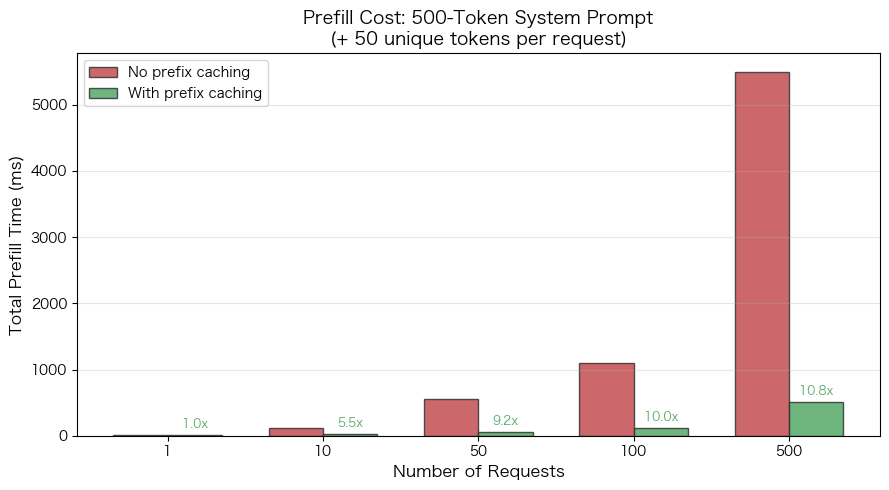

In [3]:
# Visualize: prefill time breakdown with vs without prefix caching
N_requests = [1, 10, 50, 100, 500]
prefill_ms_per_token = 0.02  # ~20 microseconds per token (A100 estimate)

no_cache_times = []
cached_times = []

for N in N_requests:
    # Without cache: every request prefills the full prompt
    total_tokens_no_cache = N * (system_prompt_tokens + avg_user_tokens)
    no_cache_times.append(total_tokens_no_cache * prefill_ms_per_token)
    
    # With cache: system prompt computed once, only user tokens per request
    total_tokens_cached = system_prompt_tokens + N * avg_user_tokens
    cached_times.append(total_tokens_cached * prefill_ms_per_token)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(N_requests))
width = 0.35

bars1 = ax.bar(x - width/2, no_cache_times, width, label="No prefix caching",
               color="#C44E52", alpha=0.85, edgecolor="#333")
bars2 = ax.bar(x + width/2, cached_times, width, label="With prefix caching",
               color="#55A868", alpha=0.85, edgecolor="#333")

ax.set_xlabel("Number of Requests", fontsize=12)
ax.set_ylabel("Total Prefill Time (ms)", fontsize=12)
ax.set_title(f"Prefill Cost: {system_prompt_tokens}-Token System Prompt\n"
             f"(+ {avg_user_tokens} unique tokens per request)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(N_requests)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Annotate speedups
for i in range(len(N_requests)):
    speedup = no_cache_times[i] / cached_times[i]
    ax.text(x[i] + width/2, cached_times[i] + max(no_cache_times) * 0.02,
            f"{speedup:.1f}x", ha="center", fontsize=9, fontweight="bold", color="#55A868")

plt.tight_layout()
plt.show()

节省量随请求数线性增长。对于一个每分钟处理 10,000 个请求、system prompt 为 500 token 的高流量端点，prefix caching 每分钟可以消除约 500 万次冗余 token 计算。

除了 system prompt，prefix caching 还适用于：
- **Few-shot 示例**：许多请求共享相同的示范样例
- **多轮对话**：先前的对话轮次是后续消息的共享前缀
- **RAG 流水线**：检索到的上下文块经常在多个查询间被复用

---
## 2. Prefix Caching 机制

核心思路非常简洁：

1. **首次请求时**：正常计算完整 prompt 的 KV-cache。将前缀的 KV 块存储在缓存中，以 token 序列的 **哈希值** 作为键。
2. **后续请求时**：对传入的 token 计算哈希，查找缓存。**缓存命中** 时，跳过匹配前缀的 prefill，直接复用已存储的 KV 块。

```
Request arrives: [tok_1, tok_2, ..., tok_500, tok_501, ..., tok_512]
                  |---- system prompt ----|  |-- user msg --|

Step 1: hash([tok_1, ..., tok_500]) → lookup in cache
Step 2: CACHE HIT → reuse KV blocks for tokens 1-500
Step 3: Only run prefill for tokens 501-512 (the unique suffix)
```

哈希在 **块粒度**（而非单个 token）上计算，以对齐 PagedAttention 基于块的内存管理方式。

In [4]:
# Demonstrate block-level hashing for prefix matching
block_size = 4  # tokens per block

def hash_token_block(token_ids):
    """Hash a block of token IDs to produce a cache key."""
    return hashlib.sha256(str(token_ids).encode()).hexdigest()[:12]

# Simulated system prompt (500 tokens) + user message (12 tokens)
system_prompt = list(range(1000, 1500))  # 500 tokens
user_message_1 = [42, 99, 7, 13, 88, 21, 55, 3, 67, 12, 44, 9]
user_message_2 = [77, 33, 51, 28, 60, 15, 82, 91, 46, 5, 70, 38]

request_1 = system_prompt + user_message_1  # 512 tokens
request_2 = system_prompt + user_message_2  # 512 tokens

# Hash each block of 4 tokens
print(f"Block size: {block_size} tokens")
print(f"System prompt: {len(system_prompt)} tokens = {len(system_prompt) // block_size} blocks")
print(f"User message:  {len(user_message_1)} tokens = {len(user_message_1) // block_size} blocks\n")

# Show first few block hashes — they match for shared prefix
print("First 5 block hashes for each request:")
print(f"{'Block':>6} | {'Request 1':>14} | {'Request 2':>14} | Match?")
print("-" * 55)

match_count = 0
total_blocks = len(request_1) // block_size
for b in range(min(total_blocks, 130)):  # check all blocks
    block_tokens_1 = request_1[b*block_size : (b+1)*block_size]
    block_tokens_2 = request_2[b*block_size : (b+1)*block_size]
    h1 = hash_token_block(block_tokens_1)
    h2 = hash_token_block(block_tokens_2)
    match = h1 == h2
    if match:
        match_count += 1
    if b < 3 or b >= len(system_prompt) // block_size - 1:  # show first 3 and transition
        print(f"{b:>6} | {h1:>14} | {h2:>14} | {'YES' if match else 'NO'}")
    elif b == 3:
        print(f"{'...':>6} | {'...':>14} | {'...':>14} | ...")

# Show the first diverging block
diverge_block = len(system_prompt) // block_size
b = diverge_block
block_tokens_1 = request_1[b*block_size : (b+1)*block_size]
block_tokens_2 = request_2[b*block_size : (b+1)*block_size]
h1 = hash_token_block(block_tokens_1)
h2 = hash_token_block(block_tokens_2)
print(f"{b:>6} | {h1:>14} | {h2:>14} | {'YES' if h1 == h2 else 'NO'} <-- first divergence")

prefix_blocks = len(system_prompt) // block_size
print(f"\nMatching blocks: {match_count}/{total_blocks} "
      f"({match_count * block_size} of {len(request_1)} tokens cached)")
print(f"Prefill saved: {match_count * block_size / len(request_1):.0%} of tokens")

Block size: 4 tokens
System prompt: 500 tokens = 125 blocks
User message:  12 tokens = 3 blocks

First 5 block hashes for each request:
 Block |      Request 1 |      Request 2 | Match?
-------------------------------------------------------
     0 |   566435cda2ad |   566435cda2ad | YES
     1 |   a6c2380bff73 |   a6c2380bff73 | YES
     2 |   4809097394e8 |   4809097394e8 | YES
   ... |            ... |            ... | ...
   124 |   bfa3e2d75a36 |   bfa3e2d75a36 | YES
   125 |   e2f86e11396d |   f95654edc539 | NO
   126 |   1c845e177aec |   b2eabedf0f33 | NO
   127 |   ed4eda0a0b04 |   699398204213 | NO
   125 |   e2f86e11396d |   f95654edc539 | NO <-- first divergence

Matching blocks: 125/128 (500 of 512 tokens cached)
Prefill saved: 98% of tokens


In [5]:
info_box(
    "<b>Why hash at block level?</b><br><br>"
    "PagedAttention stores KV-cache in fixed-size blocks (e.g., 16 tokens). "
    "The smallest unit of reuse is one block. Hashing at the block level means "
    "cache lookups align perfectly with the memory manager — a cache hit directly "
    "maps to physical blocks that can be shared via reference counting, just like "
    "the copy-on-write mechanism we saw in notebook 03.",
    title="Block-Level Hashing"
)

---
## 3. Radix Tree 结构

一种朴素的方法是对整个前缀计算哈希，然后在一个扁平的哈希表中查找。但这会错过 **部分前缀匹配** —— 如果两个请求共享前 400 个 token，但在第 401 个 token 处分叉呢？

**Radix tree**（也称为 **前缀树** 或 **trie**）解决了这个问题。从根节点到叶节点的每条路径代表一个 token 序列。树结构支持 **最长前缀匹配**：沿着传入的 token 向下遍历树，直到到达没有匹配子节点的节点。

```
             [root]
            /      \
       [sys_A]    [sys_B]        ← different system prompts
       /    \         \
  [user1] [user2]   [user3]     ← different user messages
```

关键特性：
- 每条 **边** 对应一个 token（或一组 token）
- 每个 **节点** 存储该前缀段的 KV-cache 块 ID
- **查找** 沿树向下遍历，沿途收集缓存块
- 遍历在最深匹配处停止 —— 这就是 **最长缓存前缀**

In [6]:
# Build a radix tree with the PrefixCache class
cache = PrefixCache(block_size=4)

# Insert several sequences that share common prefixes
# Use small token IDs for readability
# System prompt A: [10, 20, 30, 40, 50, 60, 70, 80]
sys_a = [10, 20, 30, 40, 50, 60, 70, 80]

# Request 1: sys_a + user_1
user_1 = [91, 92, 93, 94]
cache.insert(sys_a + user_1, block_ids=[0, 1, 2])  # 12 tokens → 3 blocks

# Request 2: sys_a + user_2 (same system prompt, different user message)
user_2 = [95, 96, 97, 98]
cache.insert(sys_a + user_2, block_ids=[0, 1, 3])  # blocks 0,1 shared with request 1

# Request 3: different system prompt
sys_b = [10, 20, 30, 40, 55, 65, 75, 85]  # diverges at token 5
user_3 = [99, 88, 77, 66]
cache.insert(sys_b + user_3, block_ids=[0, 4, 5])  # block 0 shared (first 4 tokens match)

print("Inserted 3 sequences into the prefix cache:")
print(f"  Request 1: {sys_a + user_1} → blocks [0, 1, 2]")
print(f"  Request 2: {sys_a + user_2} → blocks [0, 1, 3]")
print(f"  Request 3: {sys_b + user_3} → blocks [0, 4, 5]")
print(f"\nNote: block 0 is shared by all 3 (first 4 tokens are identical).")
print(f"Blocks 0,1 are shared by requests 1 and 2 (same 8-token system prompt).")

Inserted 3 sequences into the prefix cache:
  Request 1: [10, 20, 30, 40, 50, 60, 70, 80, 91, 92, 93, 94] → blocks [0, 1, 2]
  Request 2: [10, 20, 30, 40, 50, 60, 70, 80, 95, 96, 97, 98] → blocks [0, 1, 3]
  Request 3: [10, 20, 30, 40, 55, 65, 75, 85, 99, 88, 77, 66] → blocks [0, 4, 5]

Note: block 0 is shared by all 3 (first 4 tokens are identical).
Blocks 0,1 are shared by requests 1 and 2 (same 8-token system prompt).


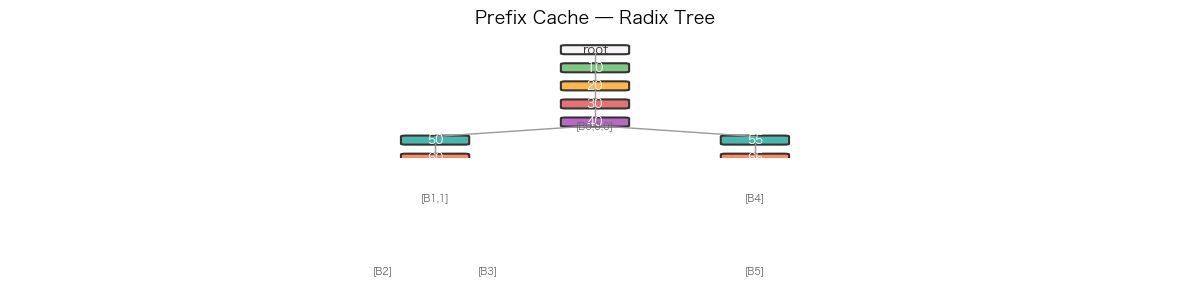

In [7]:
# Visualize the radix tree
tree_data = cache.get_tree_structure()
fig, ax = draw_radix_tree(tree_data, title="Prefix Cache — Radix Tree")
plt.show()

In [8]:
# Demonstrate longest-prefix matching
print("=== Longest-Prefix Matching ===")
print()

test_queries = [
    ("New request with same sys_a", sys_a + [11, 22, 33, 44]),
    ("New request with same sys_a + user_1 prefix", sys_a + user_1 + [100, 200]),
    ("New request with sys_b prefix", sys_b + [11, 22, 33, 44]),
    ("Completely new prefix", [1, 2, 3, 4, 5, 6, 7, 8]),
]

for label, query in test_queries:
    matched_len, cached_blocks = cache.lookup(query)
    print(f"{label}")
    print(f"  Query tokens: {query[:8]}{'...' if len(query) > 8 else ''}")
    print(f"  Matched prefix length: {matched_len} tokens")
    print(f"  Cached blocks reused:  {cached_blocks}")
    print(f"  Tokens to compute:     {len(query) - matched_len} (skip prefill for {matched_len})")
    print()

=== Longest-Prefix Matching ===

New request with same sys_a
  Query tokens: [10, 20, 30, 40, 50, 60, 70, 80]...
  Matched prefix length: 8 tokens
  Cached blocks reused:  [0, 0, 0, 1, 1]
  Tokens to compute:     4 (skip prefill for 8)

New request with same sys_a + user_1 prefix
  Query tokens: [10, 20, 30, 40, 50, 60, 70, 80]...
  Matched prefix length: 12 tokens
  Cached blocks reused:  [0, 0, 0, 1, 1, 2]
  Tokens to compute:     2 (skip prefill for 12)

New request with sys_b prefix
  Query tokens: [10, 20, 30, 40, 55, 65, 75, 85]...
  Matched prefix length: 8 tokens
  Cached blocks reused:  [0, 0, 0, 4]
  Tokens to compute:     4 (skip prefill for 8)

Completely new prefix
  Query tokens: [1, 2, 3, 4, 5, 6, 7, 8]
  Matched prefix length: 0 tokens
  Cached blocks reused:  []
  Tokens to compute:     8 (skip prefill for 0)



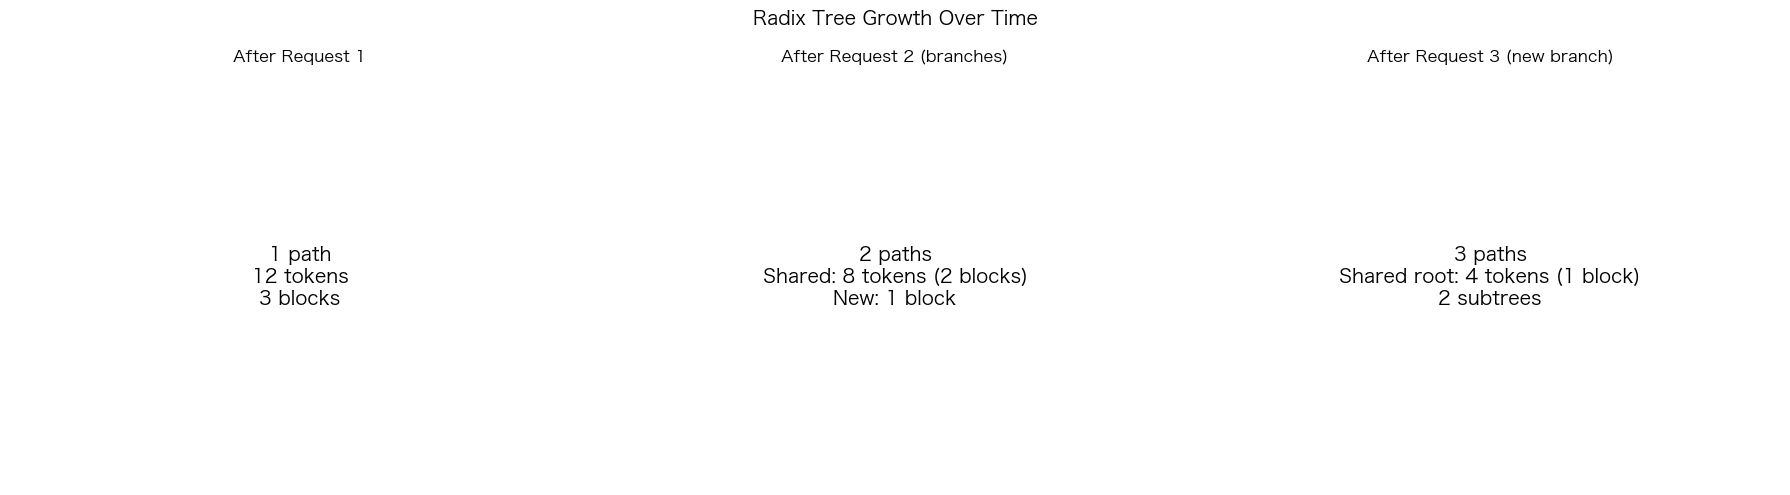

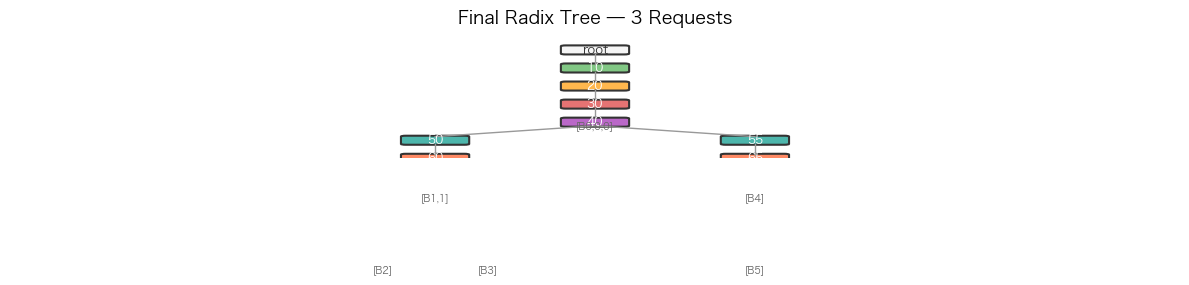

In [9]:
# Visualize tree growth as more requests arrive
cache2 = PrefixCache(block_size=4)
shared_prefix = [10, 20, 30, 40, 50, 60, 70, 80]  # 8 tokens, 2 blocks

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Step 1: first request
cache2.insert(shared_prefix + [91, 92, 93, 94], block_ids=[0, 1, 2])
tree = cache2.get_tree_structure()
ax = axes[0]
ax.set_title("After Request 1", fontsize=12, fontweight="bold")
ax.text(0.5, 0.5, "1 path\n12 tokens\n3 blocks",
        transform=ax.transAxes, ha="center", va="center", fontsize=14)
ax.axis("off")

# Step 2: second request (shares prefix)
cache2.insert(shared_prefix + [95, 96, 97, 98], block_ids=[0, 1, 3])
ax = axes[1]
ax.set_title("After Request 2 (branches)", fontsize=12, fontweight="bold")
ax.text(0.5, 0.5, "2 paths\nShared: 8 tokens (2 blocks)\nNew: 1 block",
        transform=ax.transAxes, ha="center", va="center", fontsize=14)
ax.axis("off")

# Step 3: third request (different prefix)
cache2.insert([10, 20, 30, 40, 55, 65, 75, 85, 99, 88, 77, 66], block_ids=[0, 4, 5])
ax = axes[2]
ax.set_title("After Request 3 (new branch)", fontsize=12, fontweight="bold")
ax.text(0.5, 0.5, "3 paths\nShared root: 4 tokens (1 block)\n2 subtrees",
        transform=ax.transAxes, ha="center", va="center", fontsize=14)
ax.axis("off")

fig.suptitle("Radix Tree Growth Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Show final tree
fig2, ax2 = draw_radix_tree(
    cache2.get_tree_structure(),
    title="Final Radix Tree — 3 Requests"
)
plt.show()

Radix tree 自然地捕获了传入请求的 **共享结构**。只有在 token 序列分叉的地方才会出现分支。公共前缀只存储一次，被所有匹配的请求共享。

在 SGLang 等系统中，radix tree 在 **块粒度** 而非单个 token 粒度上运作 —— 每条边代表一个 token 块，节点存储对物理 KV-cache 块的引用。

---
## 4. 与 PagedAttention 的集成

Prefix caching 与 PagedAttention（notebook 03）天然集成。回忆一下，PagedAttention 将 KV-cache 存储在由块表管理的固定大小 **块** 中。Prefix caching 在此基础上添加了一层：

1. **块哈希**：每个物理块以其 token 内容的哈希值作为键
2. **共享物理块**：缓存命中时，新请求的块表指向与缓存前缀 **相同的物理块**（引用计数防止过早释放）
3. **写时复制（copy-on-write）**：如果请求需要修改共享块（例如前缀在块中间结束），则先复制该块

```
Request A block table: [B0] → [B1] → [B2] → [B5]  (unique suffix)
                         ↑      ↑      ↑
                        shared  shared  shared
                         ↓      ↓      ↓
Request B block table: [B0] → [B1] → [B2] → [B7]  (different suffix)
```

块 B0、B1、B2 是 **物理共享的** —— GPU 显存中没有重复数据。

In [10]:
# Demonstrate prefix caching with PagedAttention block sharing
mgr = PagedKVCacheManager(num_blocks=24, block_size=4)

# Request A: system prompt (16 tokens) + user message (8 tokens)
# Allocate and fill blocks for Request A
mgr.allocate_sequence(seq_id=0)
for _ in range(24 - 1):  # 24 tokens total
    mgr.append_token(seq_id=0)

print("Request A (first request, no cache):")
print(f"  Tokens: 16 (system prompt) + 8 (user) = 24")
print(f"  Blocks: {mgr.get_block_table(0)}")
print(f"  Computed: all 24 tokens (full prefill)")
used_before = mgr.memory_usage()[0]
print(f"  Memory: {used_before} blocks\n")

# Request B arrives with same system prompt (16 tokens) but different user message
# With prefix caching: fork the first 4 blocks (16 tokens of shared prefix)
# then allocate new blocks only for the unique suffix
mgr.fork_sequence(src_seq_id=0, new_seq_id=1)  # share all blocks initially

# In practice, the unique suffix blocks would be replaced.
# For demonstration, we add more tokens to the forked sequence.
for _ in range(4):  # 4 more unique tokens for request B
    mgr.append_token(seq_id=1)

print("Request B (cache hit on 16-token prefix):")
print(f"  Blocks: {mgr.get_block_table(1)}")
print(f"  Shared prefix blocks: first 4 blocks (16 tokens)")
print(f"  New blocks for suffix: {mgr.memory_usage()[0] - used_before}")
print(f"  Computed: only 8 unique tokens (skipped 16-token prefill!)")
print(f"  Memory: {mgr.memory_usage()[0]} blocks total (vs {used_before + 7} without sharing)")

Request A (first request, no cache):
  Tokens: 16 (system prompt) + 8 (user) = 24
  Blocks: [0, 1, 2, 3, 4, 5]
  Computed: all 24 tokens (full prefill)
  Memory: 6 blocks

Request B (cache hit on 16-token prefix):
  Blocks: [0, 1, 2, 3, 4, 5, 6]
  Shared prefix blocks: first 4 blocks (16 tokens)
  New blocks for suffix: 1
  Computed: only 8 unique tokens (skipped 16-token prefill!)
  Memory: 7 blocks total (vs 13 without sharing)


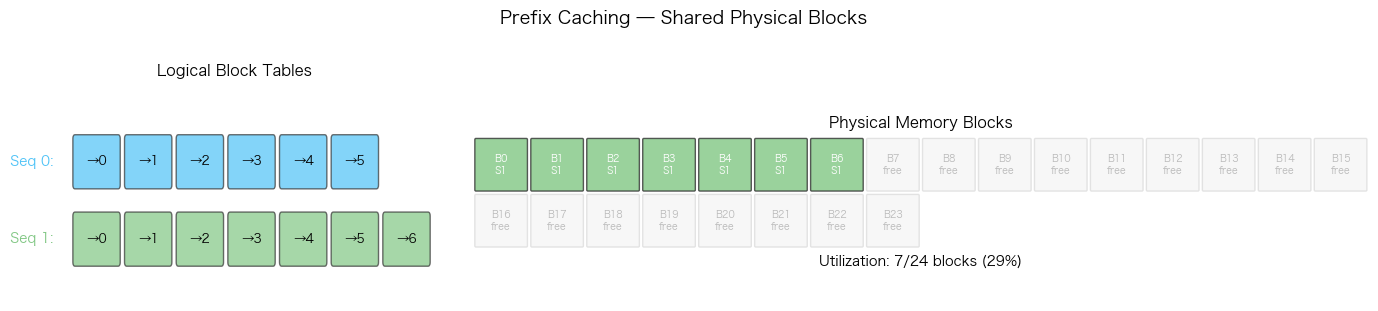

In [11]:
# Visualize the shared block layout
fig, axes = draw_block_table(
    mgr, seq_ids=[0, 1],
    title="Prefix Caching — Shared Physical Blocks"
)
plt.show()

System prompt: 512 tokens = 32 blocks
User message:  64 tokens = 4 blocks
Block size:    16 tokens

N requests |   No sharing | With sharing |      Saved |  Savings
--------------------------------------------------------------
         1 |         36 blk |         36 blk |        0 blk |      0%
         5 |        180 blk |         52 blk |      128 blk |     71%
        10 |        360 blk |         72 blk |      288 blk |     80%
        50 |       1800 blk |        232 blk |     1568 blk |     87%
       100 |       3600 blk |        432 blk |     3168 blk |     88%
       500 |      18000 blk |       2032 blk |    15968 blk |     89%


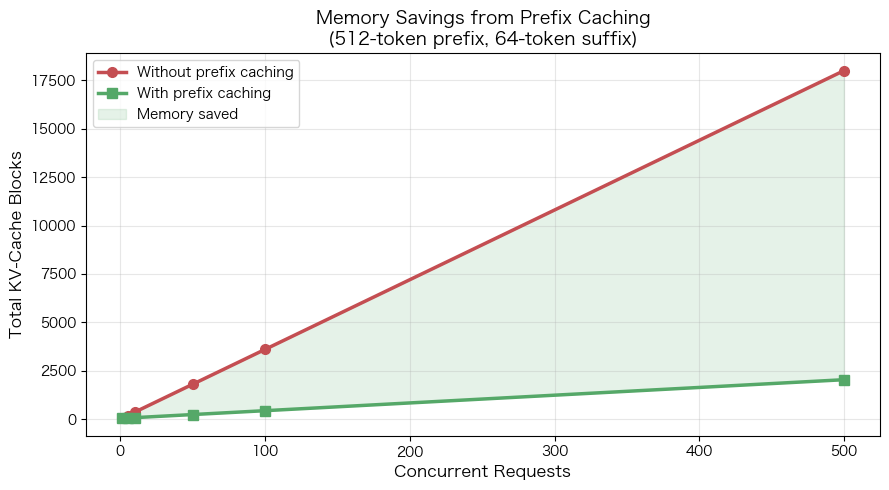

In [12]:
# Scale up: memory savings with N requests sharing a prefix
block_size = 16  # realistic block size
system_prompt_tokens = 512
user_tokens = 64
prefix_blocks = system_prompt_tokens // block_size  # 32 blocks for prefix
suffix_blocks = math.ceil(user_tokens / block_size)  # 4 blocks per user msg

N_values = [1, 5, 10, 50, 100, 500]

print(f"System prompt: {system_prompt_tokens} tokens = {prefix_blocks} blocks")
print(f"User message:  {user_tokens} tokens = {suffix_blocks} blocks")
print(f"Block size:    {block_size} tokens\n")

print(f"{'N requests':>10} | {'No sharing':>12} | {'With sharing':>12} | {'Saved':>10} | {'Savings':>8}")
print("-" * 62)

for N in N_values:
    no_share = N * (prefix_blocks + suffix_blocks)
    with_share = prefix_blocks + N * suffix_blocks  # prefix stored once
    saved = no_share - with_share
    pct = saved / no_share
    print(f"{N:>10} | {no_share:>10} blk | {with_share:>10} blk | {saved:>8} blk | {pct:>7.0%}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
no_share_vals = [N * (prefix_blocks + suffix_blocks) for N in N_values]
with_share_vals = [prefix_blocks + N * suffix_blocks for N in N_values]

ax.plot(N_values, no_share_vals, 'o-', color="#C44E52", linewidth=2.5,
        markersize=7, label="Without prefix caching")
ax.plot(N_values, with_share_vals, 's-', color="#55A868", linewidth=2.5,
        markersize=7, label="With prefix caching")
ax.fill_between(N_values, with_share_vals, no_share_vals,
                alpha=0.15, color="#55A868", label="Memory saved")

ax.set_xlabel("Concurrent Requests", fontsize=12)
ax.set_ylabel("Total KV-Cache Blocks", fontsize=12)
ax.set_title(f"Memory Savings from Prefix Caching\n"
             f"({system_prompt_tokens}-token prefix, {user_tokens}-token suffix)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

当 $N$ 增大时，节省量趋近于：

$$\text{Savings} \approx \frac{(N-1) \cdot P}{N \cdot (P + U)} \xrightarrow{N \to \infty} \frac{P}{P + U}$$

其中 $P$ = 前缀块数，$U$ = 每个请求的独特后缀块数。对于 512 token 的 system prompt 和 64 token 的用户消息，渐近节省量为 $\frac{32}{32+4} \approx 89\%$。

---
## 5. 缓存淘汰与管理

GPU 显存是有限的。前缀缓存不可能存储它见过的每一个前缀。当缓存已满而新前缀需要空间时，系统必须 **淘汰（evict）** 已缓存的条目。

最常用的策略是 **LRU（Least Recently Used，最近最少使用）** 淘汰：
- 每个缓存的前缀记录最后一次被访问的时间
- 当缓存已满时，最近最少使用的条目优先被淘汰
- 频繁访问的前缀（如主 system prompt）会留在缓存中

根本的权衡是：**缓存大小 vs. 命中率**。更大的缓存可以存储更多前缀，获得更高的命中率，但会消耗原本可以用于服务更多并发请求的 GPU 显存。

In [13]:
# Simulate LRU cache behavior with varying cache sizes
import collections

class LRUPrefixCache:
    """Simplified LRU prefix cache for simulation."""
    def __init__(self, max_entries):
        self.max_entries = max_entries
        self.cache = collections.OrderedDict()  # key → value, LRU order
        self.hits = 0
        self.misses = 0
    
    def access(self, key):
        """Look up a prefix key. Returns True on hit, False on miss."""
        if key in self.cache:
            self.cache.move_to_end(key)  # mark as recently used
            self.hits += 1
            return True
        else:
            self.misses += 1
            # Insert, evicting LRU if full
            if len(self.cache) >= self.max_entries:
                self.cache.popitem(last=False)  # remove LRU entry
            self.cache[key] = True
            return False
    
    @property
    def hit_rate(self):
        total = self.hits + self.misses
        return self.hits / total if total > 0 else 0.0


# Simulate a realistic workload:
# - 5 system prompts (with Zipf-like popularity)
# - 200 unique user messages per prompt
# - 2000 total requests
np.random.seed(42)

n_prompts = 5
n_users_per_prompt = 200
n_requests = 2000

# Zipf distribution: prompt 0 is most popular
prompt_probs = np.array([1/(i+1) for i in range(n_prompts)])
prompt_probs /= prompt_probs.sum()

# Generate request stream
request_stream = []
for _ in range(n_requests):
    prompt_id = np.random.choice(n_prompts, p=prompt_probs)
    user_id = np.random.randint(0, n_users_per_prompt)
    # Cache key is just the system prompt (we cache at prefix level)
    request_stream.append(f"prompt_{prompt_id}")

print(f"Workload: {n_requests} requests across {n_prompts} system prompts")
print(f"Prompt distribution: {dict(zip(range(n_prompts), [f'{p:.0%}' for p in prompt_probs]))}\n")

# Test different cache sizes
cache_sizes = [1, 2, 3, 5, 10, 20]
hit_rates = []

print(f"{'Cache Size':>10} | {'Hits':>6} | {'Misses':>6} | {'Hit Rate':>8}")
print("-" * 40)

for size in cache_sizes:
    lru = LRUPrefixCache(max_entries=size)
    for key in request_stream:
        lru.access(key)
    hit_rates.append(lru.hit_rate)
    print(f"{size:>10} | {lru.hits:>6} | {lru.misses:>6} | {lru.hit_rate:>7.1%}")

Workload: 2000 requests across 5 system prompts
Prompt distribution: {0: '44%', 1: '22%', 2: '15%', 3: '11%', 4: '9%'}

Cache Size |   Hits | Misses | Hit Rate
----------------------------------------
         1 |    566 |   1434 |   28.3%
         2 |   1052 |    948 |   52.6%
         3 |   1450 |    550 |   72.5%
         5 |   1995 |      5 |   99.8%
        10 |   1995 |      5 |   99.8%
        20 |   1995 |      5 |   99.8%


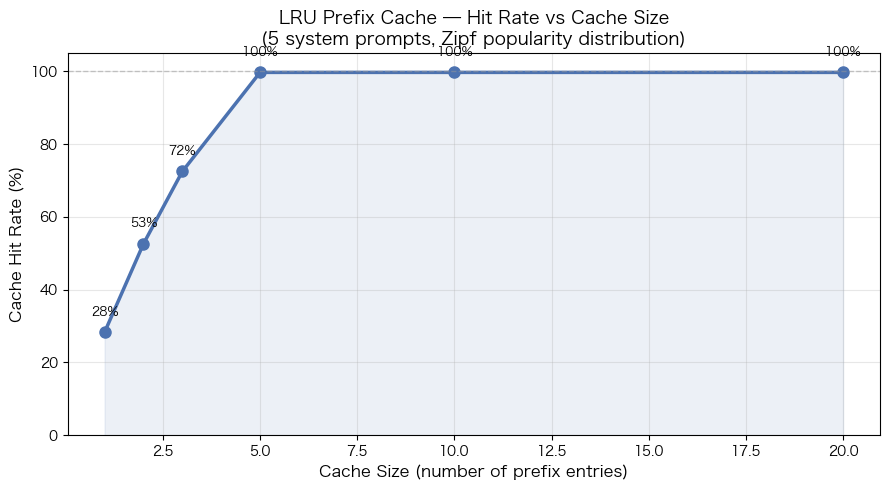

With just 5 cache entries for 5 prompts, hit rate reaches 100%
The Zipf distribution means a small cache captures most of the benefit.


In [14]:
# Plot cache size vs hit rate
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(cache_sizes, [hr * 100 for hr in hit_rates], 'o-',
        color="#4C72B0", linewidth=2.5, markersize=8)
ax.fill_between(cache_sizes, [hr * 100 for hr in hit_rates],
                alpha=0.1, color="#4C72B0")

# Annotate key points
for i, (size, hr) in enumerate(zip(cache_sizes, hit_rates)):
    ax.annotate(f"{hr:.0%}", (size, hr * 100),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, fontweight="bold")

ax.axhline(100, color="#999", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Cache Size (number of prefix entries)", fontsize=12)
ax.set_ylabel("Cache Hit Rate (%)", fontsize=12)
ax.set_title(f"LRU Prefix Cache — Hit Rate vs Cache Size\n"
             f"({n_prompts} system prompts, Zipf popularity distribution)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"With just {n_prompts} cache entries for {n_prompts} prompts, hit rate reaches "
      f"{hit_rates[cache_sizes.index(5)]:.0%}")
print(f"The Zipf distribution means a small cache captures most of the benefit.")

In [15]:
# Compute the end-to-end throughput impact
# Assume: prefill is the bottleneck, prefix is 500 tokens, suffix is 50 tokens
prefix_tokens = 500
suffix_tokens = 50
prefill_time_per_token_ms = 0.02  # A100 estimate

comparison_table(
    headers=["Scenario", "Prefill Tokens / Request", "Prefill Time (ms)", "Throughput Gain"],
    rows=[
        ["No caching",
         f"{prefix_tokens + suffix_tokens}",
         f"{(prefix_tokens + suffix_tokens) * prefill_time_per_token_ms:.1f}",
         "1.0x (baseline)"],
        ["Prefix cache hit",
         f"{suffix_tokens} (skip {prefix_tokens})",
         f"{suffix_tokens * prefill_time_per_token_ms:.1f}",
         f"{(prefix_tokens + suffix_tokens) / suffix_tokens:.1f}x"],
        ["Partial hit (50%)",
         f"{prefix_tokens // 2 + suffix_tokens} (skip {prefix_tokens // 2})",
         f"{(prefix_tokens // 2 + suffix_tokens) * prefill_time_per_token_ms:.1f}",
         f"{(prefix_tokens + suffix_tokens) / (prefix_tokens // 2 + suffix_tokens):.1f}x"],
    ],
    title="Prefill Speedup from Prefix Caching"
)

Scenario,Prefill Tokens / Request,Prefill Time (ms),Throughput Gain
No caching,550,11.0,1.0x (baseline)
Prefix cache hit,50 (skip 500),1.0,11.0x
Partial hit (50%),300 (skip 250),6.0,1.8x


In [16]:
# Show the memory tradeoff: cache memory vs serving capacity
# Model: LLaMA-7B on 80 GB GPU
gpu_memory_gb = 80
model_weights_gb = 14  # FP16
available_for_kv = gpu_memory_gb - model_weights_gb  # 66 GB

prefix_tokens = 500
kv_per_token_mb = 0.5  # LLaMA-7B, all layers, FP16
prefix_cache_mb = prefix_tokens * kv_per_token_mb  # memory per cached prefix

per_request_kv_mb = 50 * kv_per_token_mb  # unique suffix (50 tokens)

cache_prefix_counts = [0, 1, 5, 10, 20, 50]

print(f"GPU: {gpu_memory_gb} GB | Model: {model_weights_gb} GB | Available for KV: {available_for_kv} GB")
print(f"Per cached prefix: {prefix_cache_mb:.0f} MB | Per request suffix: {per_request_kv_mb:.0f} MB\n")

print(f"{'Cached Prefixes':>15} | {'Cache Memory':>12} | {'Remaining':>10} | {'Max Concurrent':>14}")
print("-" * 60)

for n_cached in cache_prefix_counts:
    cache_mem_gb = n_cached * prefix_cache_mb / 1024
    remaining_gb = available_for_kv - cache_mem_gb
    # Without caching: each request needs prefix + suffix
    # With caching: each request only needs suffix (prefix is shared)
    if n_cached == 0:
        per_req = (prefix_tokens + 50) * kv_per_token_mb / 1024  # GB
    else:
        per_req = per_request_kv_mb / 1024  # GB, only suffix
    max_concurrent = int(remaining_gb / per_req) if per_req > 0 else 0
    print(f"{n_cached:>15} | {cache_mem_gb:>10.1f} GB | {remaining_gb:>8.1f} GB | {max_concurrent:>14,}")

print(f"\nTradeoff: caching {10} prefixes uses {10 * prefix_cache_mb / 1024:.1f} GB but "
      f"allows each request to skip {prefix_tokens}-token prefill.")

GPU: 80 GB | Model: 14 GB | Available for KV: 66 GB
Per cached prefix: 250 MB | Per request suffix: 25 MB

Cached Prefixes | Cache Memory |  Remaining | Max Concurrent
------------------------------------------------------------
              0 |        0.0 GB |     66.0 GB |            245
              1 |        0.2 GB |     65.8 GB |          2,693
              5 |        1.2 GB |     64.8 GB |          2,653
             10 |        2.4 GB |     63.6 GB |          2,603
             20 |        4.9 GB |     61.1 GB |          2,503
             50 |       12.2 GB |     53.8 GB |          2,203

Tradeoff: caching 10 prefixes uses 2.4 GB but allows each request to skip 500-token prefill.


缓存内存的投入在两方面获得回报：
1. **延迟**：缓存命中时跳过 prefill，降低首 token 延迟（time-to-first-token）
2. **吞吐量**：跳过 prefill 释放了计算资源，可以处理更多请求

最优缓存大小取决于工作负载：
- **少量不同前缀**（如一个聊天机器人 system prompt）：小缓存，接近 100% 命中率
- **大量不同前缀**（如每用户独立上下文）：需要更大缓存，Zipf 分布有利
- **多轮对话**：缓存随对话深度增长，LRU 淘汰过期会话

---
## 总结

| 概念 | 核心思想 | 收益 |
|---------|----------|--------|
| **冗余 prefill** | N 个相同前缀的请求重复计算 N 次 KV | 识别了浪费所在 |
| **Prefix caching** | 对前缀 token 计算哈希，缓存 KV 块，命中时复用 | 跳过冗余 prefill |
| **Radix tree** | 树结构实现最长前缀匹配 | 处理部分匹配和多前缀场景 |
| **块级集成** | 在 PagedAttention 块粒度上进行哈希和共享 | 通过引用计数实现零拷贝共享 |
| **LRU 淘汰** | 缓存满时淘汰最近最少使用的前缀 | 有限内存下保持高命中率 |

Prefix caching 与以下技术结合使用效果尤为显著：
- **PagedAttention**（notebook 03）：块级内存管理使高效共享成为可能
- **Continuous batching**（notebook 02）：新请求可以立即受益于缓存的前缀

### 实现了 prefix caching 的系统
- **SGLang** —— 基于 radix tree 的 prefix caching，与 PagedAttention 配合
- **vLLM** —— 自动 prefix caching（基于哈希的块匹配）
- **Anthropic、OpenAI** —— 为 API 用户提供的服务端 prompt caching

### 延伸阅读
- [SGLang: Efficiently Programming Large Language Models (Zheng et al., 2023)](https://arxiv.org/abs/2312.07104)
- [vLLM Automatic Prefix Caching](https://docs.vllm.ai/en/latest/automatic_prefix_caching/apc.html)
- 下一个 notebook：**[05-quantization-pruning](05-quantization-pruning.ipynb)** —— 通过减小模型大小加速推理